# The Fourth Circle: Neural Networks, Part Two 
## Convolutional Neural Networks VI

<br/>
Jiří Fejlek

2026-03-13
<br/>

In this smaller project, we will introduce ResNet from 2015 [[1](#1)], which won the 2015 ImageNet Large Scale Visual Recognition Challenge (ILSVRC). As convolutional neural network architectures grew deeper and deeper, their training became increasingly difficult. It was observed that training deeper neural networks actually the training error actually started to *increase*. While a deeper network is usually more expressive, and thus, "better" than a shallower one, the larger deeper network does not necessarily encompass the shallower one. This means that in general, a deeper network is simply different, and thus it might actually be "worse."


The solution to these issues with deep neural network architectures proved to be actually quite simple and elegant: *residual* (also known as skip) connections. These allow signals to skip some layers, effectively reducing the network's depth if needed. 


## Table of Contents

- [ResNet](#resnet)
    - [Residual Block](#resnet-block)
    - [ResNet-18](#ResNet-18)
    - [ResNet-50](#ResNet-50)
    - [Custom ResNets for Fashion-MNIST and CIFAR-10](#ResNet-custom)
    - [Stochastic Depth](#stochdepth)
- [Inception-ResNet](#Inception-ResNet)
- [ResNeXt](#acn)
- [References](#references)


## ResNet <a class="anchor" id="resnet"></a>

We start with an implementation of the original ResNet architecture [[1](#1)]. Let us first repeat our block of functions we used for training CNNs in the previous projects.

In [1]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt

import torchvision
import torch

from torch import nn
from torch.utils.data import DataLoader

np.set_printoptions(legacy='1.25')

In [2]:
cuda_device = torch.device('cuda')
torch.cuda.get_device_name(cuda_device)

'NVIDIA GeForce RTX 4070 Ti'

In [3]:
def layer_summary(nn_model, X_shape):
    X = torch.randn(*X_shape)
    for layer in nn_model.net_stack:
        X = layer(X)
        print(layer.__class__.__name__, 'output shape:\t', X.shape)

In [4]:
def init_weights_he(model):
    if isinstance(model, nn.Linear):
        nn.init.kaiming_normal_(model.weight, nonlinearity = 'relu') 
        nn.init.constant_(model.bias, 0) 
    if isinstance(model, nn.Conv2d):
        nn.init.kaiming_normal_(model.weight, nonlinearity = 'relu') 
        nn.init.constant_(model.bias, 0)  

In [5]:
def train_test_loop_cuda(train_data_loader, test_data_loader, model, loss_fn, optimizer, scheduler):
    
    softmax = torch.nn.Softmax(dim = 1)
    model.train()

    loss_sum_train  = 0
    accu_sum_train = 0
    size_train = 0

    
    for batch, (X, y) in enumerate(train_data_loader):

        X = X.to(cuda_device)
        y = y.to(cuda_device)

        optimizer.zero_grad() # zero out the gradients
        
        pred_logits = model(X) # forward pass
        loss = loss_fn(pred_logits, y) # loss evaluation 

        # Backpropagation
        loss.backward() # gradient evaluation
        optimizer.step() # SGD step
        

        # compute prediction epoch loss and accuracy
        with torch.no_grad(): # we do not need to compute the gradients
            loss_sum_train = loss_sum_train + loss*len(X)
            size_train = size_train + len(X)
            accu_sum_train = accu_sum_train + ((softmax(pred_logits).argmax(dim = 1)-y).abs() == 0).long().sum()

    # evaluate performance on the test set
    with torch.no_grad(): 
        
        loss_sum_train = loss_sum_train/size_train
        accu_sum_train = accu_sum_train/size_train
        
        model.eval() 
        loss_sum_test  = 0
        accu_sum_test = 0
        size_test = 0
        
        for batch, (X_test, y_test) in enumerate(test_data_loader):

            X_test = X_test.to(cuda_device)
            y_test = y_test.to(cuda_device)
            
            pred_logits_test = model(X_test)
            loss_sum_test = loss_sum_test + loss_fn(pred_logits_test, y_test)*len(X_test)
            accu_sum_test = accu_sum_test + ((softmax(pred_logits_test).argmax(dim = 1)-y_test).abs() == 0).long().sum()
            size_test = size_test + len(X_test)

        loss_sum_test = loss_sum_test/size_test
        accu_sum_test = accu_sum_test/size_test
        
    # learning rate step; we use loss_sum_train for ReduceLROnPlateau
    learning_rate = scheduler.get_last_lr() 
    scheduler.step() 
    
    return  loss_sum_train.detach(), loss_sum_test.detach(), learning_rate[0], accu_sum_train.detach(), accu_sum_test.detach()

### Residual Block <a class="anchor" id="resnet-block"></a>

ResNet architecture is made by stacking the following residual blocks [[1](#1)].

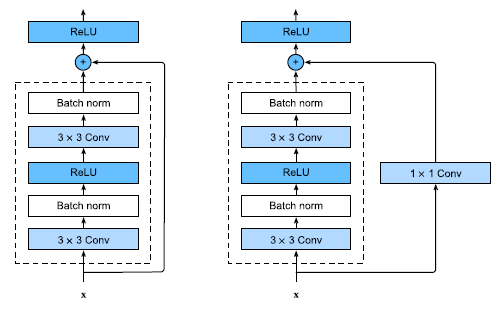

The input to the residual block is split into two branches. One branch consists of a usual stack of convolution layers. However, the second branch skips them. The output of the residual block is then a sum of these two branches. We notice that there are two versions of the residual block: we use the version with 1x1 convolution blocks when we want to change the number of output channels.

In [6]:
class Residual_block(nn.Module):

    def __init__(self, num_channels, strides = 1,  conv1x1 = False):
        super().__init__()

        # Branch 1
        self.b1 = nn.Sequential(nn.LazyConv2d(num_channels, kernel_size=3, padding=1, stride = strides), nn.LazyBatchNorm2d(), nn.ReLU(),
                                nn.LazyConv2d(num_channels, kernel_size=3, padding=1, stride = 1), nn.LazyBatchNorm2d()
        )

         # Branch 2
        if conv1x1 == True:
            self.b2 = nn.LazyConv2d(num_channels, kernel_size=1, stride = strides)
        else:
            self.b2 = None

    def forward(self, X):

        b1_x = self.b1(X)
        
        if self.b2:
            X = self.b2(X)

        b1_x += X

        return torch.nn.functional.relu(b1_x)

### ResNet-18 <a class="anchor" id="ResNet-18"></a>

Let us implement several ResNet networks based on the following table from the original paper [[1](#1)]. 

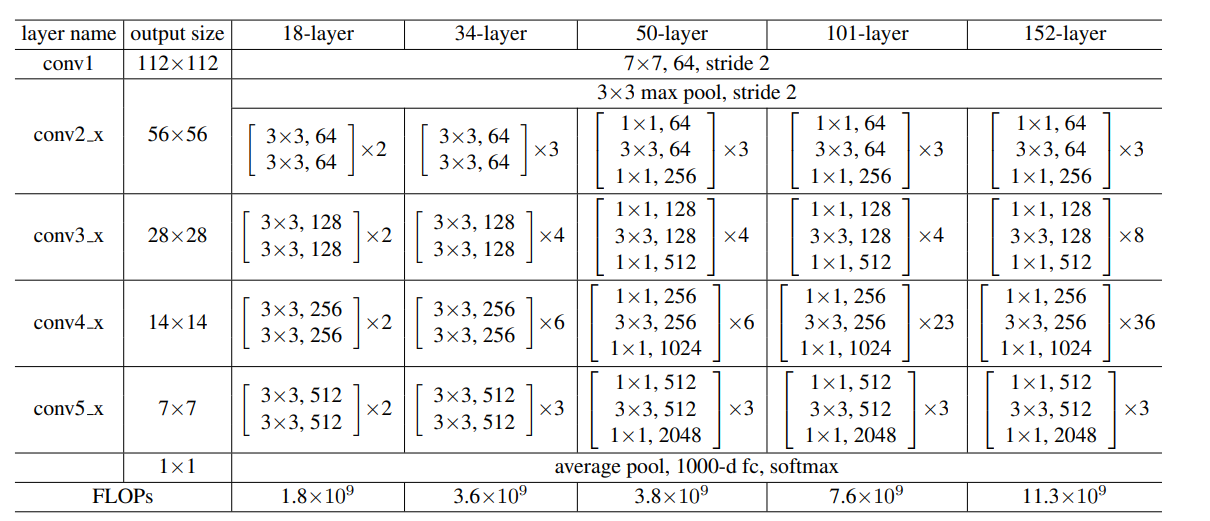

We observe that these architectures are very VGGNet-like [[2](#2)]. 

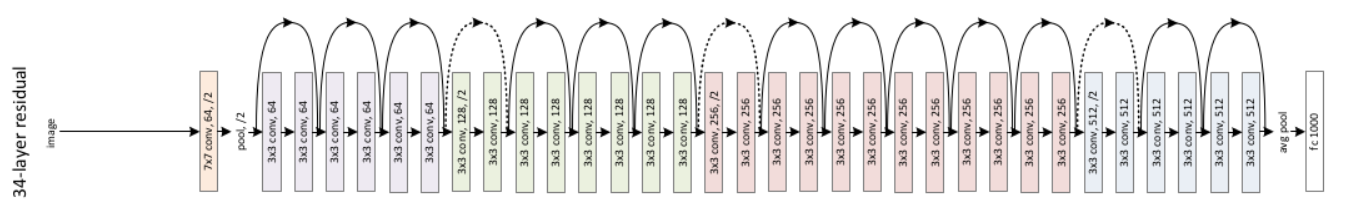

Our ResNet-18 implementation is as follows.

In [7]:
class ResNet_18(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

         # block 1
        self.b1 = nn.Sequential(
            nn.LazyConv2d(64, kernel_size=7, stride=2, padding=3),  nn.LazyBatchNorm2d(), nn.ReLU(), 
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )
        
        # residual blocks
        self.b2 =  nn.Sequential(
            Residual_block(64),
            Residual_block(64),
            Residual_block(128, strides = 2, conv1x1 = True),
            Residual_block(128),
            Residual_block(256, strides = 2, conv1x1 = True),
            Residual_block(256),
            Residual_block(512, strides = 2, conv1x1 = True),
            Residual_block(512),
        )

        self.net_stack = nn.Sequential(
            self.b1, self.b2,  nn.AdaptiveAvgPool2d((1,1)), nn.Flatten(),
            nn.LazyLinear(num_classes)
        )

    def forward(self, x):
        output = self.net_stack(x)
        return output

In [8]:
layer_summary(ResNet_18(10),(1, 1, 64, 64))

Sequential output shape:	 torch.Size([1, 64, 16, 16])
Sequential output shape:	 torch.Size([1, 512, 2, 2])
AdaptiveAvgPool2d output shape:	 torch.Size([1, 512, 1, 1])
Flatten output shape:	 torch.Size([1, 512])
Linear output shape:	 torch.Size([1, 10])


As usual, these architectures were made for large images of the ImageNet dataset. Hence, we will use these unmodified networks on the upscaled Fashion-MNIST dataset [[3](#3)].

In [9]:
torch.manual_seed(123)

# data loader
transforms_fashion_mnist_train =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(0.5, 0.5),
    torchvision.transforms.RandomHorizontalFlip(),
    torchvision.transforms.RandomResizedCrop(size = [64, 64], scale = [0.9,1.1]) 
    ]
)

transforms_fashion_mnist_test =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Resize([64,64]),
    torchvision.transforms.Normalize(0.5, 0.5)]
)

fashion_mnist_train = torchvision.datasets.FashionMNIST(root = 'D:/nine circles 2', train = True,  download = True, transform = transforms_fashion_mnist_train)
fashion_mnist_test = torchvision.datasets.FashionMNIST(root = 'D:/nine circles 2', train = False,  download = True, transform = transforms_fashion_mnist_test)

fashion_mnist_train_loader = DataLoader(dataset = fashion_mnist_train, batch_size = 250, shuffle = True) 
fashion_mnist_test_loader = DataLoader(dataset = fashion_mnist_test, batch_size = 250, shuffle = False)  


# resnet initialization
ResNet_18_cuda = ResNet_18(10).to(cuda_device)

x = (fashion_mnist_train.__getitem__(0)[0]).to(cuda_device)
x = x[None,:,:,:]
ResNet_18_cuda(x);
ResNet_18_cuda.apply(init_weights_he);

In [10]:
sum(p.numel() for p in ResNet_18_cuda.parameters() if p.requires_grad)

11178378

In [11]:
optim_SGD_cuda =  torch.optim.Adam(ResNet_18_cuda.parameters(), lr = 0.01, betas=(0.9, 0.999), weight_decay = 0)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[20, 30, 40], gamma = 0.5)
cross_entropy_loss = nn.CrossEntropyLoss(label_smoothing=0.1)

n_epochs = 50

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t], accu_epochs_train[t], accu_epochs_test[t]   = train_test_loop_cuda(fashion_mnist_train_loader, fashion_mnist_test_loader, ResNet_18_cuda, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda)
end = time.time()
print(end - start)

1556.0974690914154


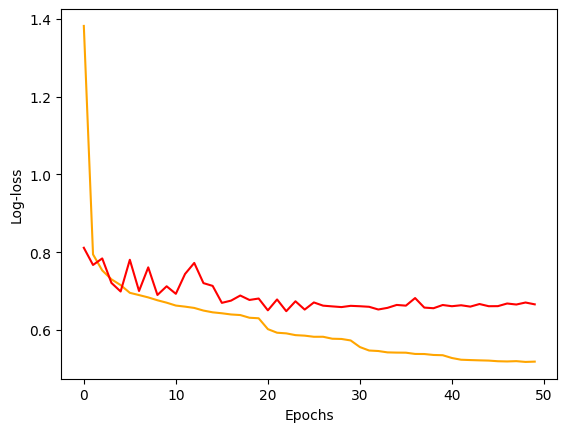

In [12]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

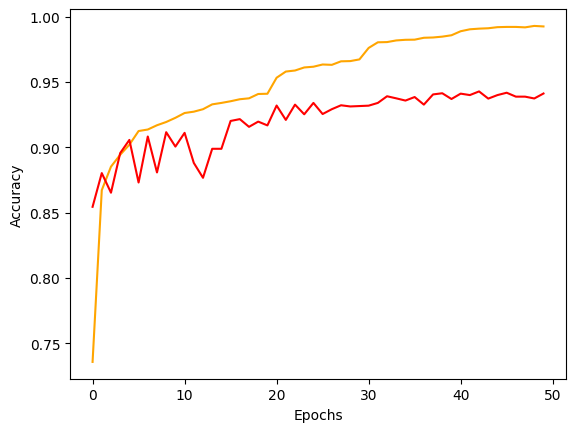

In [13]:
plt.plot(accu_epochs_train, color = 'orange')
plt.plot(accu_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy');

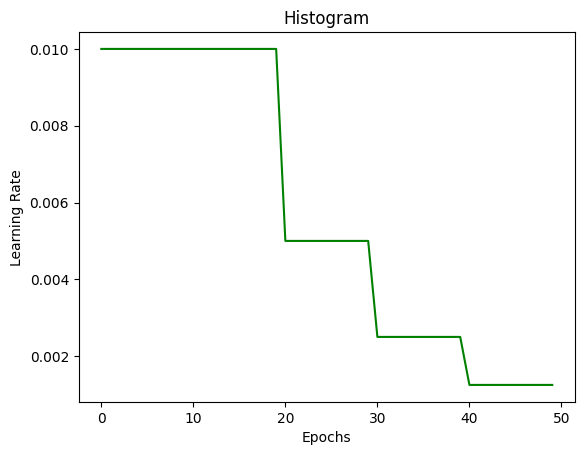

In [14]:
plt.plot(learning_rates, color = 'green')
plt.title('Histogram')
plt.xlabel('Epochs')
plt.ylabel('Learning Rate');

In [15]:
accu_epochs_train[49]

0.9925166964530945

In [16]:
accu_epochs_test[49]

0.9411999583244324

In [17]:
accu_epochs_test.max()

0.942799985408783

We obtained a respectable performance. This is actually our best model so far on the Fashion MNIST dataset.

### ResNet-50 <a class="anchor" id="ResNet-50"></a>

Next, we will implement ResNet-50. As can be seen from the table of the various ResNet architectures, ResNet-50 includes so-called bottleneck blocks [[1](#1)].

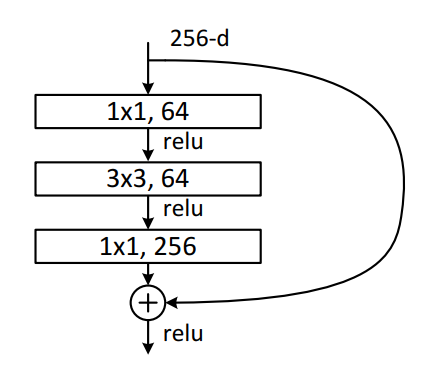

In [18]:
class Residual_bottleneck_block(nn.Module):

    def __init__(self, num_channels, strides = 1,  conv1x1 = False):
        super().__init__()

        # Branch 1
        self.b1 = nn.Sequential(
            nn.LazyConv2d(num_channels[0], kernel_size=1), nn.LazyBatchNorm2d(), nn.ReLU(),
            nn.LazyConv2d(num_channels[1], kernel_size=3, padding=1, stride = strides), nn.LazyBatchNorm2d(), nn.ReLU(),
            nn.LazyConv2d(num_channels[2], kernel_size=1), nn.LazyBatchNorm2d()
        )

         # Branch 2
        if conv1x1 == True:
            self.b2 = nn.LazyConv2d(num_channels[2], kernel_size=1, stride = strides)
        else:
            self.b2 = None

    def forward(self, X):

        b1_x = self.b1(X)
        
        if self.b2:
            X = self.b2(X)

        b1_x += X

        return torch.nn.functional.relu(b1_x)

Otherwise, the implementation is pretty straightforward.

In [19]:
class ResNet_50(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

         # block 1
        self.b1 = nn.Sequential(
            nn.LazyConv2d(64, kernel_size=7, stride=2, padding=3),  nn.LazyBatchNorm2d(), nn.ReLU(), 
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )
        
        # residual blocks
        self.b2 =  nn.Sequential(
            Residual_bottleneck_block([64,64,256], strides = 1, conv1x1 = True),
            Residual_bottleneck_block([64,64,256]),
            Residual_bottleneck_block([64,64,256]),
            Residual_bottleneck_block([128,128,512], strides = 2, conv1x1 = True),
            Residual_bottleneck_block([128,128,512]),
            Residual_bottleneck_block([128,128,512]),
            Residual_bottleneck_block([128,128,512]),
            Residual_bottleneck_block([256,256,1024], strides = 2, conv1x1 = True),
            Residual_bottleneck_block([256,256,1024]),
            Residual_bottleneck_block([256,256,1024]),
            Residual_bottleneck_block([256,256,1024]),
            Residual_bottleneck_block([256,256,1024]),
            Residual_bottleneck_block([256,256,1024]),
            Residual_bottleneck_block([512,512,2048], strides = 2, conv1x1 = True),
            Residual_bottleneck_block([512,512,2048]),
            Residual_bottleneck_block([512,512,2048])
        )

        self.net_stack = nn.Sequential(
            self.b1, self.b2,  nn.AdaptiveAvgPool2d((1,1)), nn.Flatten(),
            nn.LazyLinear(num_classes)
        )

    def forward(self, x):
        output = self.net_stack(x)
        return output

In [20]:
layer_summary(ResNet_50(10),(1, 1, 64, 64))

Sequential output shape:	 torch.Size([1, 64, 16, 16])
Sequential output shape:	 torch.Size([1, 2048, 2, 2])
AdaptiveAvgPool2d output shape:	 torch.Size([1, 2048, 1, 1])
Flatten output shape:	 torch.Size([1, 2048])
Linear output shape:	 torch.Size([1, 10])


Let us train ResNet-50 on the same problem as ResNet-18.

In [21]:
torch.manual_seed(123)

# data loader
transforms_fashion_mnist_train =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(0.5, 0.5),
    torchvision.transforms.RandomHorizontalFlip(),
    torchvision.transforms.RandomResizedCrop(size = [64, 64], scale = [0.9,1.1]) 
    ]
)

transforms_fashion_mnist_test =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Resize([64,64]),
    torchvision.transforms.Normalize(0.5, 0.5)]
)

fashion_mnist_train = torchvision.datasets.FashionMNIST(root = 'D:/nine circles 2', train = True,  download = True, transform = transforms_fashion_mnist_train)
fashion_mnist_test = torchvision.datasets.FashionMNIST(root = 'D:/nine circles 2', train = False,  download = True, transform = transforms_fashion_mnist_test)

fashion_mnist_train_loader = DataLoader(dataset = fashion_mnist_train, batch_size = 250, shuffle = True) 
fashion_mnist_test_loader = DataLoader(dataset = fashion_mnist_test, batch_size = 250, shuffle = False)

# resnet initialization
ResNet_50_cuda = ResNet_50(10).to(cuda_device)

x = (fashion_mnist_train.__getitem__(0)[0]).to(cuda_device)
x = x[None,:,:,:]
ResNet_50_cuda(x);
ResNet_50_cuda.apply(init_weights_he);

In [22]:
sum(p.numel() for p in ResNet_50_cuda.parameters() if p.requires_grad)

23541130

In [23]:
optim_SGD_cuda =  torch.optim.Adam(ResNet_50_cuda.parameters(), lr = 0.01, betas=(0.9, 0.999), weight_decay = 0)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[20, 30, 40], gamma = 0.5)
cross_entropy_loss = nn.CrossEntropyLoss(label_smoothing=0.1)

n_epochs = 50

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t], accu_epochs_train[t], accu_epochs_test[t]   = train_test_loop_cuda(fashion_mnist_train_loader, fashion_mnist_test_loader, ResNet_50_cuda, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda)
end = time.time()
print(end - start)

1953.4479911327362


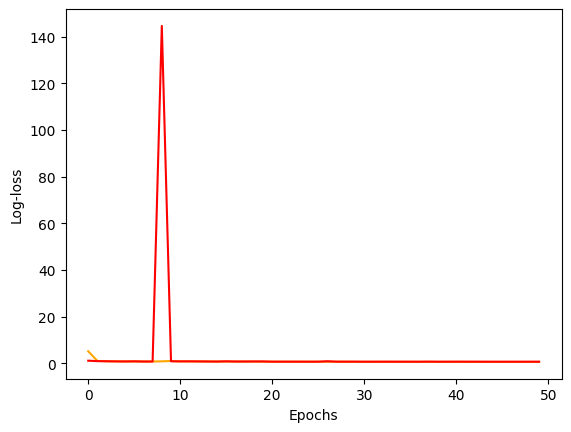

In [24]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

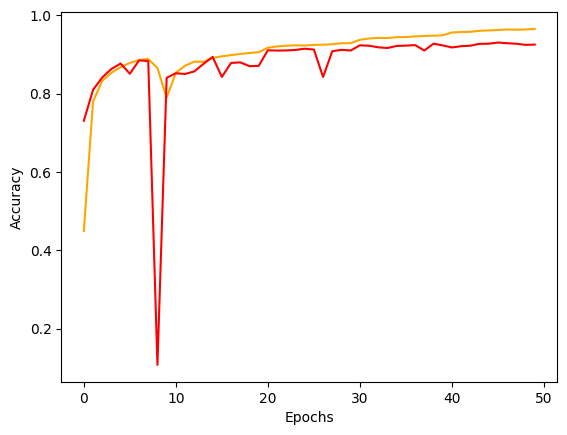

In [25]:
plt.plot(accu_epochs_train, color = 'orange')
plt.plot(accu_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy');

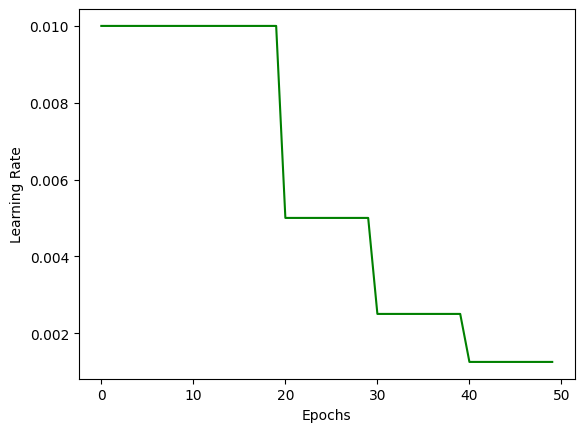

In [26]:
plt.plot(learning_rates, color = 'green')
plt.xlabel('Epochs')
plt.ylabel('Learning Rate');

In [27]:
accu_epochs_train[49]

0.9655500054359436

In [28]:
accu_epochs_test[49]

0.9254999756813049

In [29]:
accu_epochs_test.max()

0.9307999610900879

The performance is slightly worse. We would probably need to dedicate more training epochs to obtain the same performance as with the smaller Resnet-18. 

### Custom ResNets for Fashion-MNIST and CIFAR-10 <a class="anchor" id="ResNet-custom"></a>

Let us now design a new ResNet network better tuned for the Fashion-MNIST dataset.

In [30]:
class ResNet_31(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        
        # residual blocks
        self.b =  nn.Sequential(
            Residual_block(16, strides = 1, conv1x1 = True),
            Residual_block(16),
            Residual_block(16),
            Residual_block(16),
            Residual_block(16),
            Residual_block(32, strides = 2, conv1x1 = True),
            Residual_block(32),
            Residual_block(32),
            Residual_block(32),
            Residual_block(32),
            Residual_block(64, strides = 2, conv1x1 = True),
            Residual_block(64),
            Residual_block(64),
            Residual_block(64),
            Residual_block(64),
        )

        self.net_stack = nn.Sequential(
            self.b,  nn.AdaptiveAvgPool2d((1,1)), nn.Flatten(),
            nn.LazyLinear(num_classes)
        )

    def forward(self, x):
        output = self.net_stack(x)
        return output

In [31]:
torch.manual_seed(123)

# data loader
transforms_fashion_mnist_train =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(0.5, 0.5),
    torchvision.transforms.RandomHorizontalFlip(),
    torchvision.transforms.RandomResizedCrop(size = [28, 28], scale = [0.9,1.1]) 
    ]
)

transforms_fashion_mnist_test =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Resize([28,28]),
    torchvision.transforms.Normalize(0.5, 0.5)]
)

fashion_mnist_train = torchvision.datasets.FashionMNIST(root = 'D:/nine circles 2', train = True,  download = True, transform = transforms_fashion_mnist_train)
fashion_mnist_test = torchvision.datasets.FashionMNIST(root = 'D:/nine circles 2', train = False,  download = True, transform = transforms_fashion_mnist_test)

fashion_mnist_train_loader = DataLoader(dataset = fashion_mnist_train, batch_size = 250, shuffle = True) 
fashion_mnist_test_loader = DataLoader(dataset = fashion_mnist_test, batch_size = 250, shuffle = False)

# resnet initialization
ResNet_31_cuda = ResNet_31(10).to(cuda_device)

x = (fashion_mnist_train.__getitem__(0)[0]).to(cuda_device)
x = x[None,:,:,:]
ResNet_31_cuda(x);
ResNet_31_cuda.apply(init_weights_he);

In [32]:
sum(p.numel() for p in ResNet_31_cuda.parameters() if p.requires_grad)

465338

In [33]:
optim_SGD_cuda =  torch.optim.Adam(ResNet_31_cuda.parameters(), lr = 0.01, betas=(0.9, 0.999), weight_decay = 0)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[20, 30, 40], gamma = 0.5)
cross_entropy_loss = nn.CrossEntropyLoss(label_smoothing=0.1)

n_epochs = 50

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t], accu_epochs_train[t], accu_epochs_test[t]   = train_test_loop_cuda(fashion_mnist_train_loader, fashion_mnist_test_loader, ResNet_31_cuda, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda)
end = time.time()
print(end - start)

1574.9092178344727


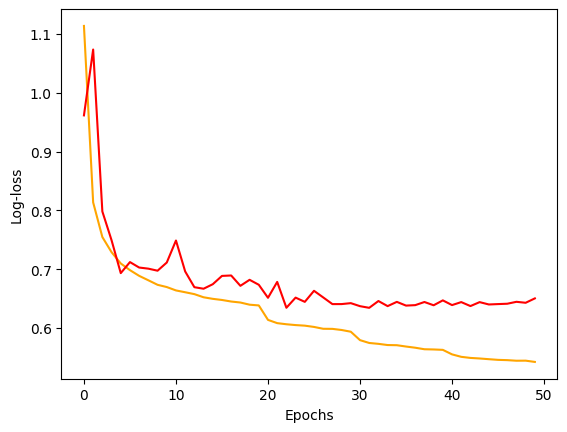

In [34]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

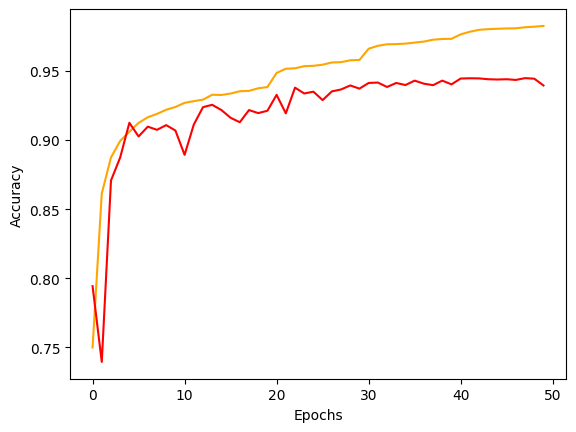

In [35]:
plt.plot(accu_epochs_train, color = 'orange')
plt.plot(accu_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy');

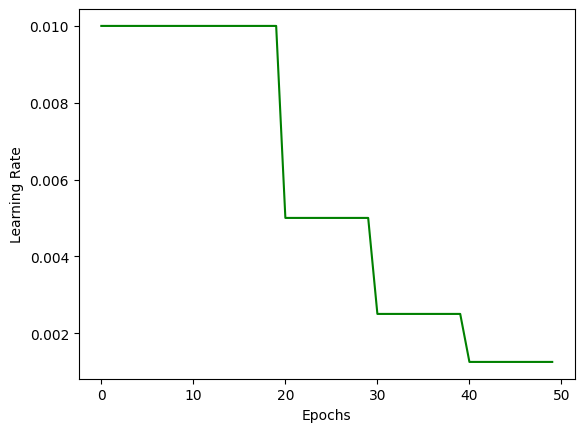

In [36]:
plt.plot(learning_rates, color = 'green')
plt.xlabel('Epochs')
plt.ylabel('Learning Rate');

In [37]:
accu_epochs_train[49]

0.9825666546821594

In [38]:
accu_epochs_test[49]

0.9394999742507935

In [39]:
accu_epochs_test.max()

0.9447999596595764

We managed to do slightly better than with ResNet-11.

Next, let us move to the CIFAR-10 dataset. We should note that the original paper [[1](#1)] describes several ResNet architectures for CIFAR-10, achieving respectable accuracy over 93%. However, these models are fairly large and would take several hours to train on a single GPU. Hence, we will demonstrate a slightly smaller ResNet network that reached almost 92% accuracy in just one hour of training.

In [40]:
class ResNet_31_2(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        
        # residual blocks
        self.b =  nn.Sequential(
            Residual_block(128, strides = 1, conv1x1 = True),
            Residual_block(128),
            Residual_block(128),
            Residual_block(128),
            Residual_block(128),
            Residual_block(256, strides = 2, conv1x1 = True),
            Residual_block(256),
            Residual_block(256),
            Residual_block(256),
            Residual_block(256),
            Residual_block(512, strides = 2, conv1x1 = True),
            Residual_block(512),
            Residual_block(512),
            Residual_block(512),
            Residual_block(512)
        )

        self.net_stack = nn.Sequential(
            self.b,  nn.AdaptiveAvgPool2d((1,1)), nn.Flatten(),
            nn.LazyLinear(num_classes)
        )

    def forward(self, x):
        output = self.net_stack(x)
        return output

In [41]:
torch.manual_seed(123)

transforms_cifar10_train =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize([0.4914, 0.4822, 0.4465], [0.2470, 0.2435, 0.2616]),
    torchvision.transforms.RandomHorizontalFlip(),
    torchvision.transforms.RandomResizedCrop(size=[32,32], scale = [0.8, 1.4]),
    ]
)

transforms_cifar10_test =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize([0.4914, 0.4822, 0.4465], [0.2470, 0.2435, 0.2616])]
)

cifar10_train = torchvision.datasets.CIFAR10(root = 'D:/nine circles 2', train = True,  download = True, transform = transforms_cifar10_train)
cifar10_test = torchvision.datasets.CIFAR10(root = 'D:/nine circles 2', train = False,  download = True, transform = transforms_cifar10_test)


cifar10_train_loader = DataLoader(dataset = cifar10_train, batch_size = 250, shuffle = True) 
cifar10_test_loader = DataLoader(dataset = cifar10_test, batch_size = 250, shuffle = False)

# resnet initialization
ResNet_31_2_cuda = ResNet_31_2(10).to(cuda_device)

x = (cifar10_train.__getitem__(0)[0]).to(cuda_device)
x = x[None,:,:,:]
ResNet_31_2_cuda(x);
ResNet_31_2_cuda.apply(init_weights_he);

optim_SGD_cuda = torch.optim.Adam(ResNet_31_2_cuda.parameters(), lr = 0.01, betas=(0.9, 0.999), weight_decay = 0)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[20,30,40], gamma = 0.5)
cross_entropy_loss = nn.CrossEntropyLoss(label_smoothing=0.1)

n_epochs = 50

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t], accu_epochs_train[t], accu_epochs_test[t]  = train_test_loop_cuda(cifar10_train_loader, cifar10_test_loader, ResNet_31_2_cuda, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda)
end = time.time()
print(end - start)

3618.370203733444


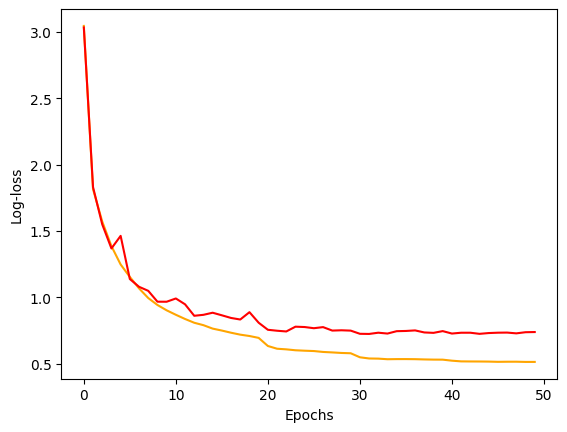

In [42]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

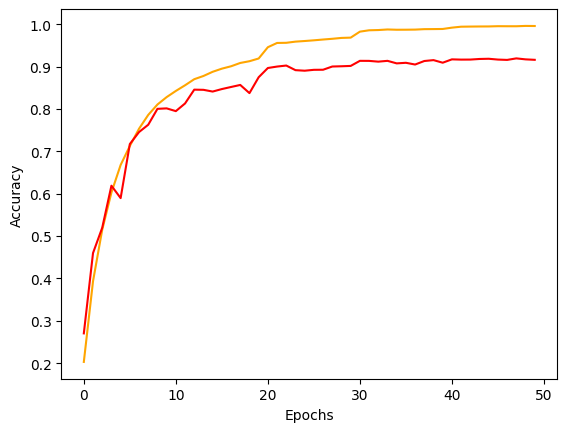

In [43]:
plt.plot(accu_epochs_train, color = 'orange')
plt.plot(accu_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy');

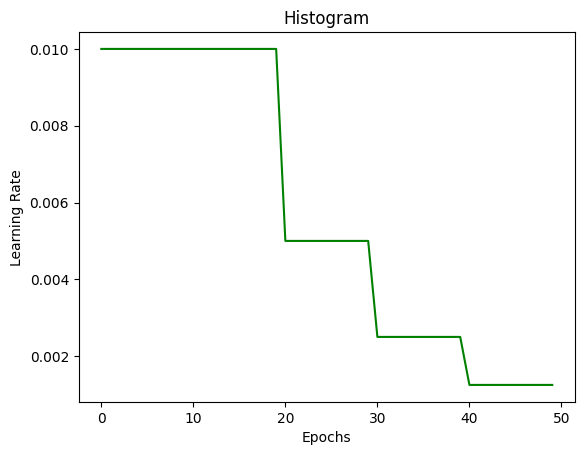

In [44]:
plt.plot(learning_rates, color = 'green')
plt.title('Histogram')
plt.xlabel('Epochs')
plt.ylabel('Learning Rate');

In [45]:
accu_epochs_train[49]

0.9958199858665466

In [46]:
accu_epochs_test[49]

0.9159999489784241

In [47]:
accu_epochs_test.max()

0.9193999767303467

### Stochastic Depth <a class="anchor" id="stochdepth"></a>

There is a small trick, akin to dropout, known as *stochastic depth* that is associated with residual blocks [[4](#4)]. This modification to residual connections is pretty simple: each residual block is ignored during training with some small probability. Consequently, we train a bit shallower network than the final network will be, which speeds up training. The numerical experiments also showed that ResNet with stochastic depth achieved higher accuracy on benchmarks (almost 95% on CIFAR-10) [[4](#4)].

Fortunately, stochastic depth is implemented in PyTorch. 

In [48]:
from torchvision.ops import StochasticDepth

In [49]:
class Residual_block_stochdepth(nn.Module):

    def __init__(self, num_channels, stoch_depth_prob, strides = 1,  conv1x1 = False):
        super().__init__()

        # Branch 1
        self.b1 = nn.Sequential(nn.LazyConv2d(num_channels, kernel_size=3, padding=1, stride = strides), nn.LazyBatchNorm2d(), nn.ReLU(),
                                nn.LazyConv2d(num_channels, kernel_size=3, padding=1, stride = 1), nn.LazyBatchNorm2d()
        )

         # Branch 2
        if conv1x1 == True:
            self.b2 = nn.LazyConv2d(num_channels, kernel_size=1, stride = strides)
        else:
            self.b2 = None

        self.stochastic_depth = StochasticDepth(p = stoch_depth_prob, mode = 'row')

    def forward(self, X):

        b1_x = self.stochastic_depth(input = self.b1(X))
        
        if self.b2:
            X = self.b2(X)

        b1_x += X

        return torch.nn.functional.relu(b1_x)

Let us augment our ResNet that we trained on CIFAR-10 with stochastic depth.

In [50]:
class ResNet_31_2_sch(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        
        # residual blocks
        self.b =  nn.Sequential(
            Residual_block_stochdepth(128, stoch_depth_prob = 0.2, strides = 1, conv1x1 = True),
            Residual_block_stochdepth(128, stoch_depth_prob = 0.2),
            Residual_block_stochdepth(128, stoch_depth_prob = 0.2),
            Residual_block_stochdepth(128, stoch_depth_prob = 0.2),
            Residual_block_stochdepth(128, stoch_depth_prob = 0.2),
            Residual_block_stochdepth(256, stoch_depth_prob = 0.2, strides = 2, conv1x1 = True),
            Residual_block_stochdepth(256, stoch_depth_prob = 0.2),
            Residual_block_stochdepth(256, stoch_depth_prob = 0.2),
            Residual_block_stochdepth(256, stoch_depth_prob = 0.2),
            Residual_block_stochdepth(256, stoch_depth_prob = 0.2),
            Residual_block_stochdepth(512, stoch_depth_prob = 0.2, strides = 2, conv1x1 = True),
            Residual_block_stochdepth(512, stoch_depth_prob = 0.2),
            Residual_block_stochdepth(512, stoch_depth_prob = 0.2),
            Residual_block_stochdepth(512, stoch_depth_prob = 0.2),
            Residual_block_stochdepth(512, stoch_depth_prob = 0.2)
        )

        self.net_stack = nn.Sequential(
            self.b,  nn.AdaptiveAvgPool2d((1,1)), nn.Flatten(),
            nn.LazyLinear(num_classes)
        )

    def forward(self, x):
        output = self.net_stack(x)
        return output

In [51]:
torch.manual_seed(123)

transforms_cifar10_train =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize([0.4914, 0.4822, 0.4465], [0.2470, 0.2435, 0.2616]),
    torchvision.transforms.RandomHorizontalFlip(),
    torchvision.transforms.RandomResizedCrop(size=[32,32], scale = [0.8, 1.4]),
    ]
)

transforms_cifar10_test =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize([0.4914, 0.4822, 0.4465], [0.2470, 0.2435, 0.2616])]
)

cifar10_train = torchvision.datasets.CIFAR10(root = 'D:/nine circles 2', train = True,  download = True, transform = transforms_cifar10_train)
cifar10_test = torchvision.datasets.CIFAR10(root = 'D:/nine circles 2', train = False,  download = True, transform = transforms_cifar10_test)


cifar10_train_loader = DataLoader(dataset = cifar10_train, batch_size = 250, shuffle = True) 
cifar10_test_loader = DataLoader(dataset = cifar10_test, batch_size = 250, shuffle = False)

# resnet initialization
ResNet_31_2_sch_cuda = ResNet_31_2_sch(10).to(cuda_device)

x = (cifar10_train.__getitem__(0)[0]).to(cuda_device)
x = x[None,:,:,:]
ResNet_31_2_sch_cuda(x);
ResNet_31_2_sch_cuda.apply(init_weights_he);

optim_SGD_cuda = torch.optim.Adam(ResNet_31_2_sch_cuda.parameters(), lr = 0.01, betas=(0.9, 0.999), weight_decay = 0)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[20,30,40], gamma = 0.5)
cross_entropy_loss = nn.CrossEntropyLoss(label_smoothing=0.1)

n_epochs = 50

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t], accu_epochs_train[t], accu_epochs_test[t]  = train_test_loop_cuda(cifar10_train_loader, cifar10_test_loader, ResNet_31_2_sch_cuda, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda)
end = time.time()
print(end - start)

3657.2601506710052


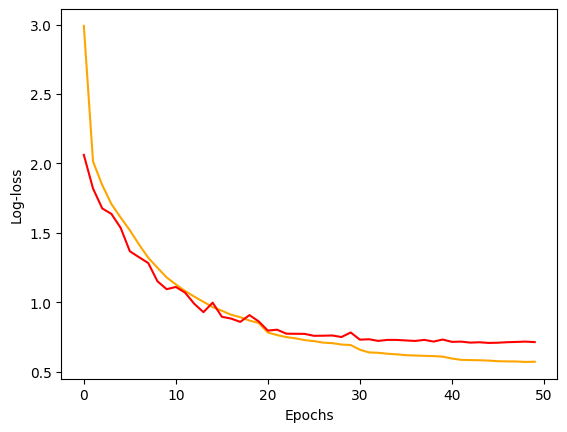

In [52]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

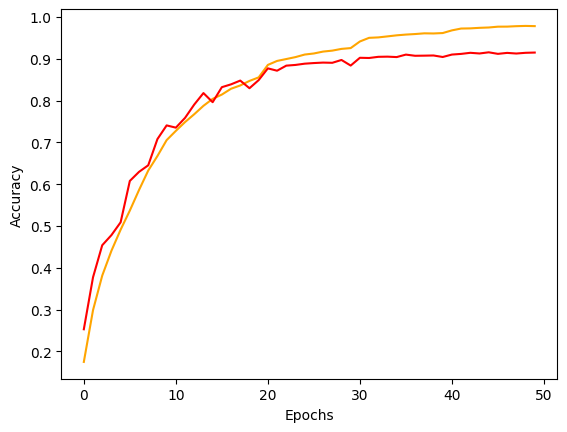

In [53]:
plt.plot(accu_epochs_train, color = 'orange')
plt.plot(accu_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy');

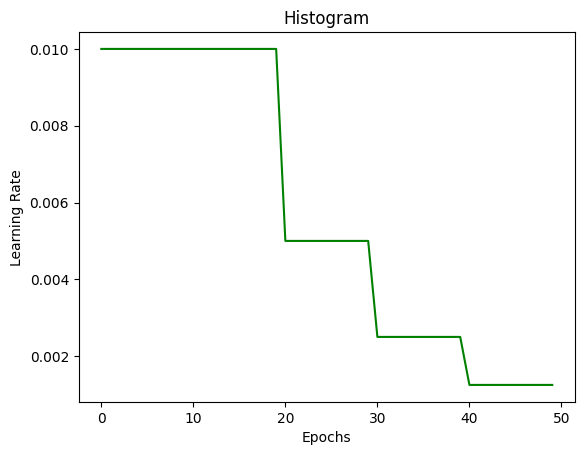

In [54]:
plt.plot(learning_rates, color = 'green')
plt.title('Histogram')
plt.xlabel('Epochs')
plt.ylabel('Learning Rate');

In [55]:
accu_epochs_train[49]

0.9780199527740479

In [56]:
accu_epochs_test[49]

0.9147999882698059

In [57]:
accu_epochs_test.max()

0.915399968624115

Unfortunately, the performance did not improve. Let us try to do a bit better with a bit deeper architecture. We will also train this network for quite a bit longer. 

In [58]:
class ResNet_37_sch(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        
        # residual blocks
        self.b =  nn.Sequential(
            Residual_block_stochdepth(32, stoch_depth_prob = 0.2, strides = 1, conv1x1 = True),
            Residual_block_stochdepth(32, stoch_depth_prob = 0.2),
            Residual_block_stochdepth(32, stoch_depth_prob = 0.2),
            Residual_block_stochdepth(32, stoch_depth_prob = 0.2),
            Residual_block_stochdepth(32, stoch_depth_prob = 0.2),
            Residual_block_stochdepth(32, stoch_depth_prob = 0.2),
            Residual_block_stochdepth(64, stoch_depth_prob = 0.2, strides = 2, conv1x1 = True),
            Residual_block_stochdepth(64, stoch_depth_prob = 0.2),
            Residual_block_stochdepth(64, stoch_depth_prob = 0.2),
            Residual_block_stochdepth(64, stoch_depth_prob = 0.2),
            Residual_block_stochdepth(64, stoch_depth_prob = 0.2),
            Residual_block_stochdepth(64, stoch_depth_prob = 0.2),
            Residual_block_stochdepth(128, stoch_depth_prob = 0.2, strides = 2, conv1x1 = True),
            Residual_block_stochdepth(128, stoch_depth_prob = 0.2),
            Residual_block_stochdepth(128, stoch_depth_prob = 0.2),
            Residual_block_stochdepth(128, stoch_depth_prob = 0.2),
            Residual_block_stochdepth(128, stoch_depth_prob = 0.2),
            Residual_block_stochdepth(128, stoch_depth_prob = 0.2)
        )

        self.net_stack = nn.Sequential(
            self.b,  nn.AdaptiveAvgPool2d((1,1)), nn.Flatten(),
            nn.LazyLinear(num_classes)
        )

    def forward(self, x):
        output = self.net_stack(x)
        return output

In [59]:
layer_summary(ResNet_37_sch(10),(1, 1, 32, 32))

Sequential output shape:	 torch.Size([1, 128, 8, 8])
AdaptiveAvgPool2d output shape:	 torch.Size([1, 128, 1, 1])
Flatten output shape:	 torch.Size([1, 128])
Linear output shape:	 torch.Size([1, 10])


In [60]:
torch.manual_seed(123)

transforms_cifar10_train =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize([0.4914, 0.4822, 0.4465], [0.2470, 0.2435, 0.2616]),
    torchvision.transforms.RandomHorizontalFlip(),
    torchvision.transforms.RandomResizedCrop(size=[32,32], scale = [0.8, 1.4]),
    ]
)

transforms_cifar10_test =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize([0.4914, 0.4822, 0.4465], [0.2470, 0.2435, 0.2616])]
)

cifar10_train = torchvision.datasets.CIFAR10(root = 'D:/nine circles 2', train = True,  download = True, transform = transforms_cifar10_train)
cifar10_test = torchvision.datasets.CIFAR10(root = 'D:/nine circles 2', train = False,  download = True, transform = transforms_cifar10_test)


cifar10_train_loader = DataLoader(dataset = cifar10_train, batch_size = 250, shuffle = True) 
cifar10_test_loader = DataLoader(dataset = cifar10_test, batch_size = 250, shuffle = False)

# resnet initialization
ResNet_37_sch_cuda = ResNet_37_sch(10).to(cuda_device)

x = (cifar10_train.__getitem__(0)[0]).to(cuda_device)
x = x[None,:,:,:]
ResNet_37_sch_cuda(x);
ResNet_37_sch_cuda.apply(init_weights_he);

optim_SGD_cuda = torch.optim.Adam(ResNet_37_sch_cuda.parameters(), lr = 0.01, betas=(0.9, 0.999), weight_decay = 0)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[150], gamma = 0.1)
cross_entropy_loss = nn.CrossEntropyLoss(label_smoothing=0.1)

n_epochs = 300

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t], accu_epochs_train[t], accu_epochs_test[t]  = train_test_loop_cuda(cifar10_train_loader, cifar10_test_loader, ResNet_37_sch_cuda, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda)
end = time.time()
print(end - start)

8641.839225769043


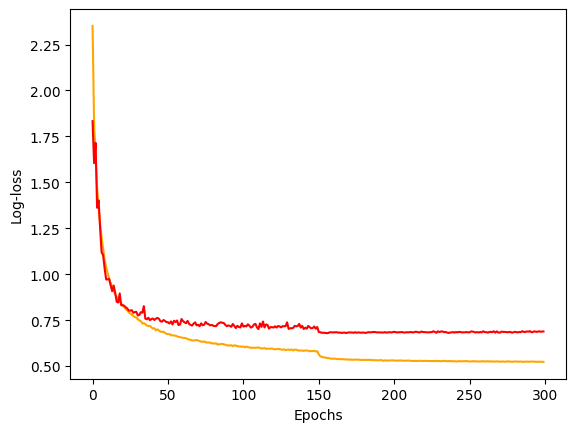

In [61]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

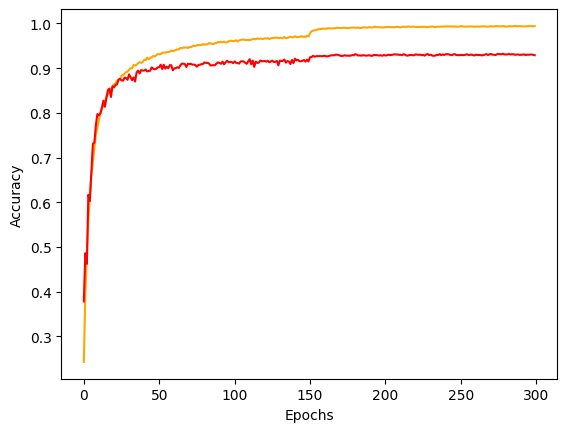

In [62]:
plt.plot(accu_epochs_train, color = 'orange')
plt.plot(accu_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy');

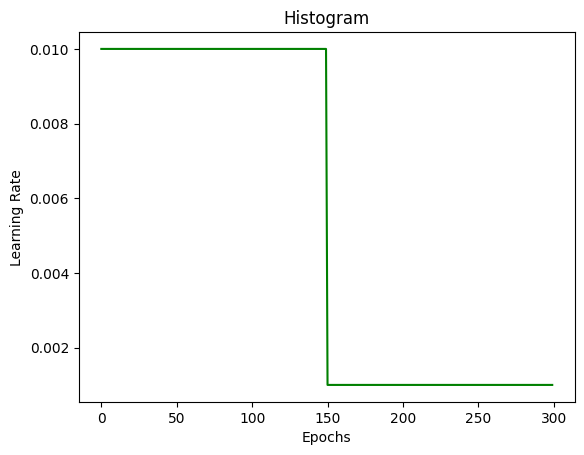

In [63]:
plt.plot(learning_rates, color = 'green')
plt.title('Histogram')
plt.xlabel('Epochs')
plt.ylabel('Learning Rate');

In [64]:
accu_epochs_train[299]

0.9941200017929077

In [65]:
accu_epochs_test[299]

0.9289999604225159

In [66]:
accu_epochs_test.max()

0.9323999881744385

We finally got over 93% test accuracy. 

## Inception-ResNet <a class="anchor" id="Inception-ResNet"></a>

The ResNet architecture was very influential in the development of later convolutional neural networks. In the same paper that introduced Inception-V4 [[5](#5)], there are also two Inception architectures with residual connections. We will implement the first one here: Inception-ResNet V1. 

We first need to implement various Inception-ResNet blocks. 

- Inception-ResNet block A

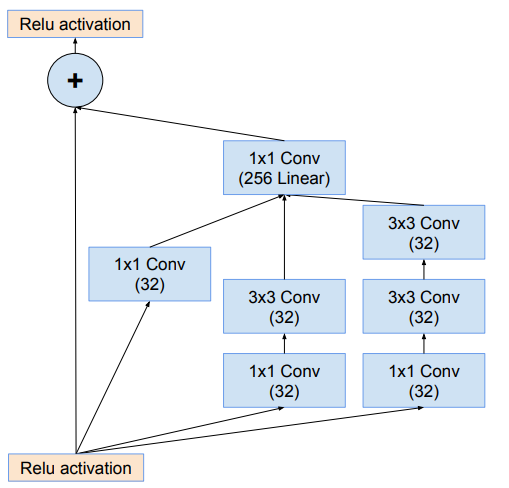

In [67]:
class Inception_resnet_A(nn.Module):
    # c1--c4 are the number of output channels for each branch
    def __init__(self, c1, c2, c3, c4):
        super().__init__()

        # Branch 1
        self.b1 = nn.Sequential(nn.LazyConv2d(c1, kernel_size=1), nn.LazyBatchNorm2d(), nn.ReLU())
        
        # Branch 2
        self.b2 = nn.Sequential(nn.LazyConv2d(c2[0], kernel_size=1), nn.LazyBatchNorm2d(), nn.ReLU(),
                                nn.LazyConv2d(c2[1], kernel_size=3, padding = 1), nn.LazyBatchNorm2d(), nn.ReLU())
        
        # Branch 3
        self.b3 = nn.Sequential(nn.LazyConv2d(c3[0], kernel_size=1), nn.LazyBatchNorm2d(), nn.ReLU(),
                                nn.LazyConv2d(c3[1], kernel_size=3, padding=1), nn.LazyBatchNorm2d(), nn.ReLU(),
                                nn.LazyConv2d(c3[1], kernel_size=3, padding=1), nn.LazyBatchNorm2d(), nn.ReLU())

        self.b4 = nn.Sequential(nn.LazyConv2d(c4, kernel_size=1), nn.LazyBatchNorm2d())
        
    def forward(self, x):
        
        branch1 = self.b1(x)
        branch2 = self.b2(x)
        branch3 = self.b3(x)
        
        y = self.b4(torch.cat((branch1, branch2, branch3), dim=1))
        y += x

        return torch.nn.functional.relu(y)

- Inception-ResNet block B

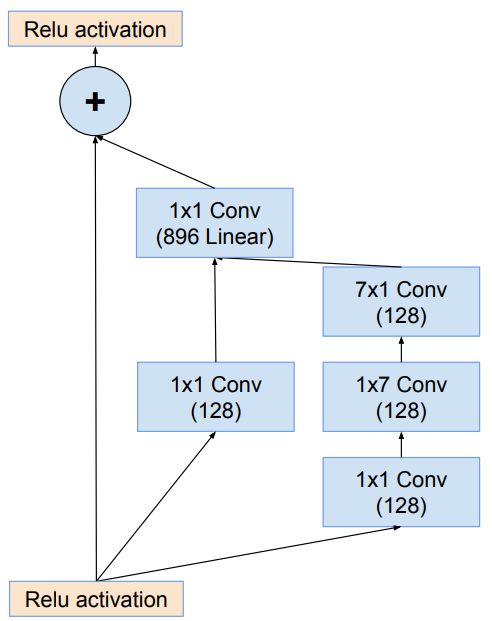

In [68]:
class Inception_resnet_B(nn.Module):
    # c1--c4 are the number of output channels for each branch
    def __init__(self, c1, c2, c3):
        super().__init__()

        # Branch 1
        self.b1 = nn.Sequential(nn.LazyConv2d(c1, kernel_size=1), nn.LazyBatchNorm2d(), nn.ReLU())
        
        # Branch 2
        self.b2 = nn.Sequential(nn.LazyConv2d(c2[0], kernel_size=1), nn.LazyBatchNorm2d(), nn.ReLU(),
                                nn.LazyConv2d(c2[1], kernel_size=(1,7), padding=(0,3)), nn.LazyBatchNorm2d(), nn.ReLU(),
                                nn.LazyConv2d(c2[1], kernel_size=(7,1), padding=(3,0)), nn.LazyBatchNorm2d(), nn.ReLU())
        
        self.b4 = nn.Sequential(nn.LazyConv2d(c3, kernel_size=1), nn.LazyBatchNorm2d())
        
    def forward(self, x):
        
        branch1 = self.b1(x)
        branch2 = self.b2(x)
 
        y = self.b4(torch.cat((branch1, branch2), dim=1))
        y += x

        return torch.nn.functional.relu(y)

- Inception-ResNet block C

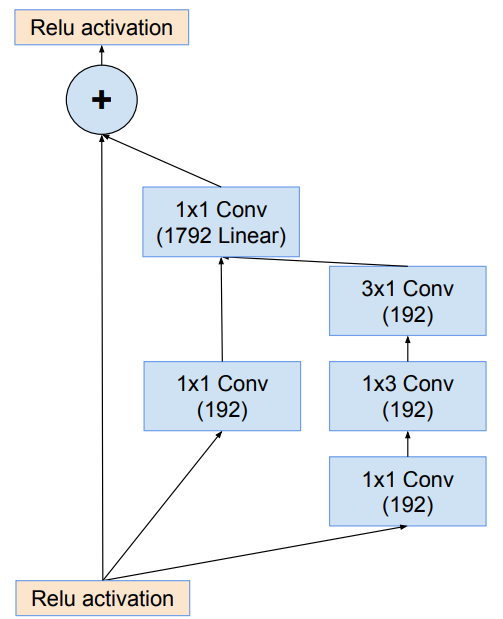

In [69]:
class Inception_resnet_C(nn.Module):
    # c1--c4 are the number of output channels for each branch
    def __init__(self, c1, c2, c3):
        super().__init__()

        # Branch 1
        self.b1 = nn.Sequential(nn.LazyConv2d(c1, kernel_size=1), nn.LazyBatchNorm2d(), nn.ReLU())
        
        # Branch 2
        self.b2 = nn.Sequential(nn.LazyConv2d(c2[0], kernel_size=1), nn.LazyBatchNorm2d(), nn.ReLU(),
                                nn.LazyConv2d(c2[1], kernel_size=(1,3), padding=(0,1)), nn.LazyBatchNorm2d(), nn.ReLU(),
                                nn.LazyConv2d(c2[1], kernel_size=(3,1), padding=(1,0)), nn.LazyBatchNorm2d(), nn.ReLU())
        
        self.b4 = nn.Sequential(nn.LazyConv2d(c3, kernel_size=1), nn.LazyBatchNorm2d())
        
    def forward(self, x):
        
        branch1 = self.b1(x)
        branch2 = self.b2(x)
 
        y = self.b4(torch.cat((branch1, branch2), dim=1))
        y += x

        return torch.nn.functional.relu(y)

- Reduction block A

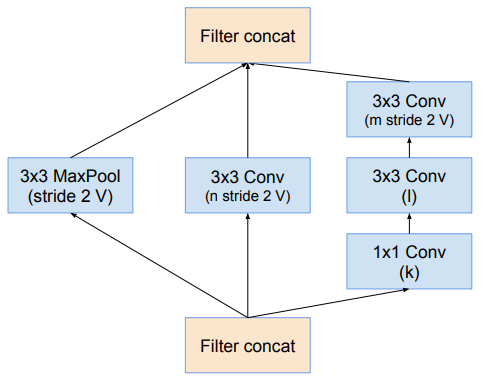

In [70]:
class Inception_resnet_A_red(nn.Module):
    # c1--c4 are the number of output channels for each branch
    def __init__(self, c1, c2):
        super().__init__()

        # Branch 1
        self.b1 = nn.Sequential(nn.LazyConv2d(c1, kernel_size=3, padding=1, stride = 2), nn.LazyBatchNorm2d(), nn.ReLU())
        
        # Branch 2
        self.b2 = nn.Sequential(nn.LazyConv2d(c2[0], kernel_size=1), nn.LazyBatchNorm2d(), nn.ReLU(),
                                nn.LazyConv2d(c2[1], kernel_size=3, padding=1), nn.LazyBatchNorm2d(), nn.ReLU(),
                                nn.LazyConv2d(c2[2], kernel_size=3, padding=1, stride = 2), nn.LazyBatchNorm2d(), nn.ReLU())

        # Branch 3
        self.b3 = nn.MaxPool2d(kernel_size=3, stride = 2, padding=1)  
        
    def forward(self, x):
        branch1 = self.b1(x)
        branch2 = self.b2(x)
        branch3 = self.b3(x)

        
        return torch.cat((branch1, branch2, branch3), dim=1)

- Reduction block B 

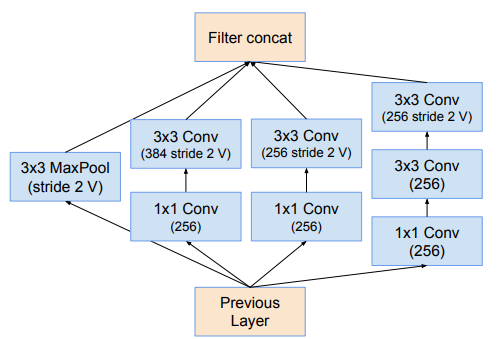

In [71]:
class Inception_resnet_B_red(nn.Module):
    # c1--c4 are the number of output channels for each branch
    def __init__(self, c1, c2, c3):
        super().__init__()

        # Branch 1
        self.b1 = nn.Sequential(nn.LazyConv2d(c1[0], kernel_size=1), nn.LazyBatchNorm2d(), nn.ReLU(),
                                nn.LazyConv2d(c1[1], kernel_size=3, stride = 2, padding=1), nn.LazyBatchNorm2d(), nn.ReLU())
        
        # Branch 2
        self.b2 = nn.Sequential(nn.LazyConv2d(c2[0], kernel_size=1), nn.LazyBatchNorm2d(), nn.ReLU(),
                                nn.LazyConv2d(c2[1], kernel_size=3, stride = 2, padding=1), nn.LazyBatchNorm2d(), nn.ReLU())
        
        # Branch 3
        self.b3 = nn.Sequential(nn.LazyConv2d(c3[0], kernel_size=1), nn.LazyBatchNorm2d(), nn.ReLU(),
                                nn.LazyConv2d(c3[1], kernel_size=3, padding=1), nn.LazyBatchNorm2d(), nn.ReLU(),
                                nn.LazyConv2d(c3[2], kernel_size=3, stride = 2, padding=1), nn.LazyBatchNorm2d(), nn.ReLU())

        # Branch 4
        self.b4 = nn.Sequential(nn.MaxPool2d(kernel_size=3, stride=2, padding=1))
        
    def forward(self, x):
        branch1 = self.b1(x)
        branch2 = self.b2(x)
        branch3 = self.b3(x)
        branch4 = self.b4(x)
        return torch.cat((branch1, branch2, branch3, branch4), dim=1)

- Stem

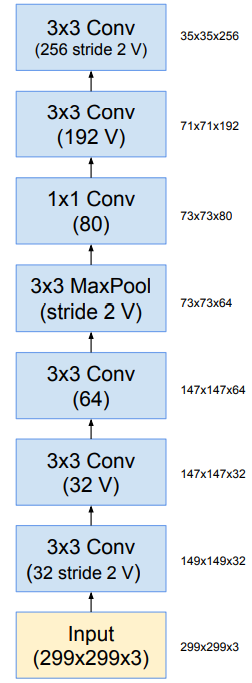

In [72]:
class Inception_resnet_stem(nn.Module):
    # c1--c4 are the number of output channels for each branch
    def __init__(self):
        super().__init__()


        self.net_stack = nn.Sequential(
            nn.LazyConv2d(32, kernel_size=3, padding=1, stride = 2), nn.LazyBatchNorm2d(), nn.ReLU(),
            nn.LazyConv2d(32, kernel_size=3, padding=1), nn.LazyBatchNorm2d(), nn.ReLU(),
            nn.LazyConv2d(64, kernel_size=3, padding=1), nn.LazyBatchNorm2d(), nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
            nn.LazyConv2d(80, kernel_size=1), nn.LazyBatchNorm2d(), nn.ReLU(),
            nn.LazyConv2d(192, kernel_size=3, padding=1), nn.LazyBatchNorm2d(), nn.ReLU(),
            nn.LazyConv2d(256, kernel_size=3, padding=1, stride = 2), nn.LazyBatchNorm2d(), nn.ReLU(),
        )

    def forward(self, x):
        output = self.net_stack(x)
        return output

Finally, we can put all these blocks together.

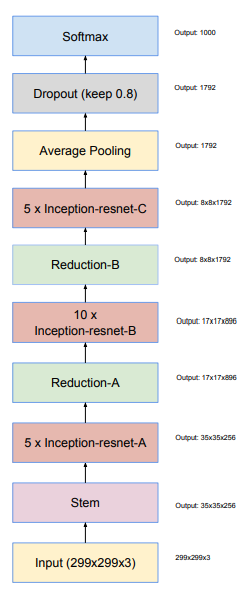

In [73]:
class Inception_resnet_v1(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        # stem
        self.stem = Inception_resnet_stem()

        # body block 1
        self.bblock1 =  nn.Sequential(
            Inception_resnet_A(32, (32, 32), (32, 32, 32), 256),
            Inception_resnet_A(32, (32, 32), (32, 32, 32), 256),
            Inception_resnet_A(32, (32, 32), (32, 32, 32), 256),
            Inception_resnet_A(32, (32, 32), (32, 32, 32), 256),
            Inception_resnet_A(32, (32, 32), (32, 32, 32), 256),
            Inception_resnet_A_red(384, (192, 192, 256))
        )

        self.bblock2 =  nn.Sequential(
            Inception_resnet_B(128, (128, 128, 128), 896),
            Inception_resnet_B(128, (128, 128, 128), 896),
            Inception_resnet_B(128, (128, 128, 128), 896),
            Inception_resnet_B(128, (128, 128, 128), 896),
            Inception_resnet_B(128, (128, 128, 128), 896),
            Inception_resnet_B(128, (128, 128, 128), 896),
            Inception_resnet_B(128, (128, 128, 128), 896),
            Inception_resnet_B(128, (128, 128, 128), 896),
            Inception_resnet_B(128, (128, 128, 128), 896),
            Inception_resnet_B(128, (128, 128, 128), 896),
            Inception_resnet_B_red((256,384), (256,256), (256, 256, 256))
        )

        self.bblock3 =  nn.Sequential(
            Inception_resnet_C(192, (192, 192, 192), 1792),
            Inception_resnet_C(192, (192, 192, 192), 1792),
            Inception_resnet_C(192, (192, 192, 192), 1792),
            Inception_resnet_C(192, (192, 192, 192), 1792),
            Inception_resnet_C(192, (192, 192, 192), 1792),
            nn.AdaptiveAvgPool2d((1,1)), nn.Flatten()
        )
        
        self.net_stack = nn.Sequential(
            self.stem, self.bblock1, self.bblock2, self.bblock3,
            nn.Dropout(0.2),
            nn.LazyLinear(num_classes)
        )

    def forward(self, x):
        output = self.net_stack(x)
        return output

In [74]:
layer_summary(Inception_resnet_v1(10),(1, 1, 96, 96))

Inception_resnet_stem output shape:	 torch.Size([1, 256, 12, 12])
Sequential output shape:	 torch.Size([1, 896, 6, 6])
Sequential output shape:	 torch.Size([1, 1792, 3, 3])
Sequential output shape:	 torch.Size([1, 1792])
Dropout output shape:	 torch.Size([1, 1792])
Linear output shape:	 torch.Size([1, 10])


Let us demonstrate Inception-ResNet V1 on upscaled images of the Fashion-MNIST dataset.

In [75]:
torch.manual_seed(123)

# data loader
transforms_fashion_mnist_train =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(0.5, 0.5),
    torchvision.transforms.RandomHorizontalFlip(),
    torchvision.transforms.RandomResizedCrop(size = [64, 64], scale = [0.9,1.1]) 
    ]
)

transforms_fashion_mnist_test =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Resize([64,64]),
    torchvision.transforms.Normalize(0.5, 0.5)]
)

fashion_mnist_train = torchvision.datasets.FashionMNIST(root = 'D:/nine circles 2', train = True,  download = True, transform = transforms_fashion_mnist_train)
fashion_mnist_test = torchvision.datasets.FashionMNIST(root = 'D:/nine circles 2', train = False,  download = True, transform = transforms_fashion_mnist_test)

fashion_mnist_train_loader = DataLoader(dataset = fashion_mnist_train, batch_size = 250, shuffle = True) 
fashion_mnist_test_loader = DataLoader(dataset = fashion_mnist_test, batch_size = 250, shuffle = False)  


# inception initialization
Inception_resnet_v1_cuda = Inception_resnet_v1(10).to(cuda_device)

x = (fashion_mnist_train.__getitem__(0)[0]).to(cuda_device)
x = x[None,:,:,:]
Inception_resnet_v1_cuda(x);
Inception_resnet_v1_cuda.apply(init_weights_he);


optim_SGD_cuda =  torch.optim.Adam(Inception_resnet_v1_cuda.parameters(), lr = 0.01, betas=(0.9, 0.999), weight_decay = 0)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[20, 30, 40], gamma = 0.5)
cross_entropy_loss = nn.CrossEntropyLoss(label_smoothing=0.1)

n_epochs = 50

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t], accu_epochs_train[t], accu_epochs_test[t]   = train_test_loop_cuda(fashion_mnist_train_loader, fashion_mnist_test_loader, Inception_resnet_v1_cuda, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda)
end = time.time()
print(end - start)

2280.127171754837


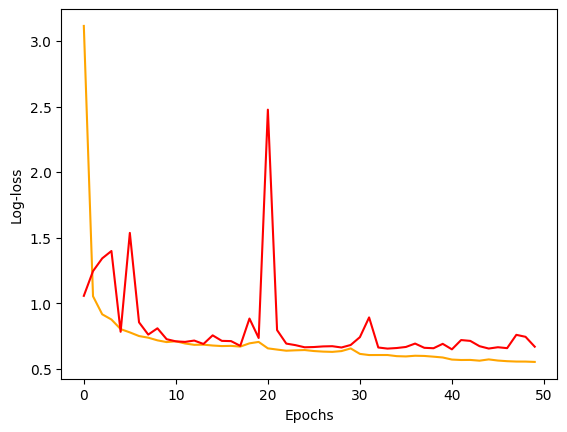

In [76]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

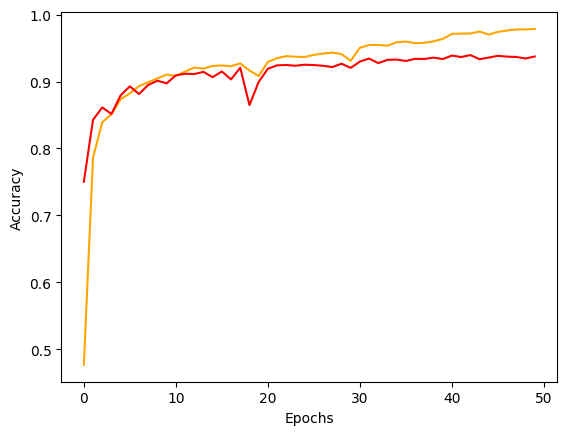

In [77]:
plt.plot(accu_epochs_train, color = 'orange')
plt.plot(accu_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy');

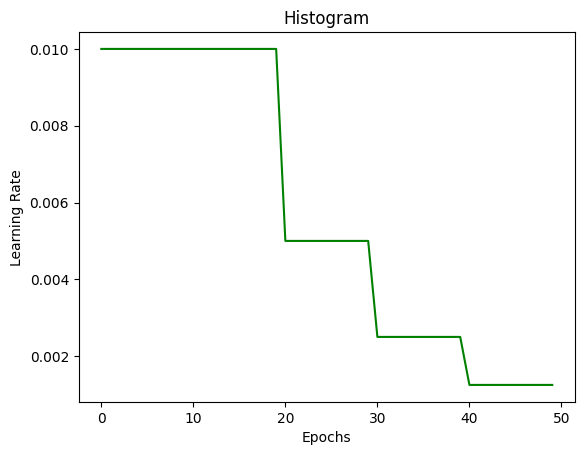

In [78]:
plt.plot(learning_rates, color = 'green')
plt.title('Histogram')
plt.xlabel('Epochs')
plt.ylabel('Learning Rate');

In [79]:
accu_epochs_train[49]

0.978600025177002

In [80]:
accu_epochs_test[49]

0.9373999834060669

In [81]:
accu_epochs_test.max()

0.9394999742507935

The Inception-ResNet performed reasonably well. Next, let us try to downscale the model to better fit the Fashion-MNIST dataset.

In [82]:
class Inception_resnet_stem_red(nn.Module):
    # c1--c4 are the number of output channels for each branch
    def __init__(self):
        super().__init__()


        self.net_stack = nn.Sequential(
            nn.LazyConv2d(32, kernel_size=3, padding=1), nn.LazyBatchNorm2d(), nn.ReLU(),
            nn.LazyConv2d(64, kernel_size=3, padding=1), nn.LazyBatchNorm2d(), nn.ReLU(),
            nn.LazyConv2d(128, kernel_size=3, padding=1), nn.LazyBatchNorm2d(), nn.ReLU(),              
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
        )

    def forward(self, x):
        output = self.net_stack(x)
        return output

In [83]:
class Inception_resnet_v1_red(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        # stem
        self.stem = Inception_resnet_stem_red()

        # body block 1
        self.bblock1 =  nn.Sequential(
            Inception_resnet_A(32, (32, 32), (32, 32, 32), 128),
            Inception_resnet_A(32, (32, 32), (32, 32, 32), 128),
            Inception_resnet_A(32, (32, 32), (32, 32, 32), 128),
            Inception_resnet_A(32, (32, 32), (32, 32, 32), 128),
            Inception_resnet_A(32, (32, 32), (32, 32, 32), 128),
            Inception_resnet_A_red(128, (96, 96, 128))
        )

        self.bblock2 =  nn.Sequential(
            Inception_resnet_B(64, (64, 64, 64), 384),
            Inception_resnet_B(64, (64, 64, 64), 384),
            Inception_resnet_B(64, (64, 64, 64), 384),
            Inception_resnet_B(64, (64, 64, 64), 384),
            Inception_resnet_B(64, (64, 64, 64), 384),
            Inception_resnet_B(64, (64, 64, 64), 384),
            Inception_resnet_B(64, (64, 64, 64), 384),
            Inception_resnet_B(64, (64, 64, 64), 384),
            Inception_resnet_B(64, (64, 64, 64), 384),
            Inception_resnet_B(64, (64, 64, 64), 384),
            Inception_resnet_B_red((128,256), (128,128), (128, 128, 128))
        )

        self.bblock3 =  nn.Sequential(
            Inception_resnet_C(128, (128, 128, 128), 896),
            Inception_resnet_C(128, (128, 128, 128), 896),
            Inception_resnet_C(128, (128, 128, 128), 896),
            Inception_resnet_C(128, (128, 128, 128), 896),
            Inception_resnet_C(128, (128, 128, 128), 896),
            nn.AdaptiveAvgPool2d((1,1)), nn.Flatten()
        )
        
        self.net_stack = nn.Sequential(
            self.stem, self.bblock1, self.bblock2, self.bblock3,
            nn.Dropout(0.2),
            nn.LazyLinear(num_classes)
        )

    def forward(self, x):
        output = self.net_stack(x)
        return output

In [84]:
layer_summary(Inception_resnet_v1_red(10),(1, 1, 28, 28))

Inception_resnet_stem_red output shape:	 torch.Size([1, 128, 14, 14])
Sequential output shape:	 torch.Size([1, 384, 7, 7])
Sequential output shape:	 torch.Size([1, 896, 4, 4])
Sequential output shape:	 torch.Size([1, 896])
Dropout output shape:	 torch.Size([1, 896])
Linear output shape:	 torch.Size([1, 10])


In [85]:
torch.manual_seed(123)

# data loader
transforms_fashion_mnist_train =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(0.5, 0.5),
    torchvision.transforms.RandomHorizontalFlip(),
    torchvision.transforms.RandomResizedCrop(size = [28, 28], scale = [0.9,1.1]) 
    ]
)

transforms_fashion_mnist_test =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Resize([28,28]),
    torchvision.transforms.Normalize(0.5, 0.5)]
)

fashion_mnist_train = torchvision.datasets.FashionMNIST(root = 'D:/nine circles 2', train = True,  download = True, transform = transforms_fashion_mnist_train)
fashion_mnist_test = torchvision.datasets.FashionMNIST(root = 'D:/nine circles 2', train = False,  download = True, transform = transforms_fashion_mnist_test)

fashion_mnist_train_loader = DataLoader(dataset = fashion_mnist_train, batch_size = 250, shuffle = True) 
fashion_mnist_test_loader = DataLoader(dataset = fashion_mnist_test, batch_size = 250, shuffle = False)  


# initialization
Inception_resnet_v1_red_cuda = Inception_resnet_v1_red(10).to(cuda_device)

x = (fashion_mnist_train.__getitem__(0)[0]).to(cuda_device)
x = x[None,:,:,:]
Inception_resnet_v1_red_cuda(x);
Inception_resnet_v1_red_cuda.apply(init_weights_he);


optim_SGD_cuda =  torch.optim.Adam(Inception_resnet_v1_red_cuda.parameters(), lr = 0.01, betas=(0.9, 0.999), weight_decay = 0)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[20, 30, 40], gamma = 0.5)
cross_entropy_loss = nn.CrossEntropyLoss(label_smoothing=0.1)

n_epochs = 50

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t], accu_epochs_train[t], accu_epochs_test[t]   = train_test_loop_cuda(fashion_mnist_train_loader, fashion_mnist_test_loader, Inception_resnet_v1_red_cuda, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda)
end = time.time()
print(end - start)

2090.7863776683807


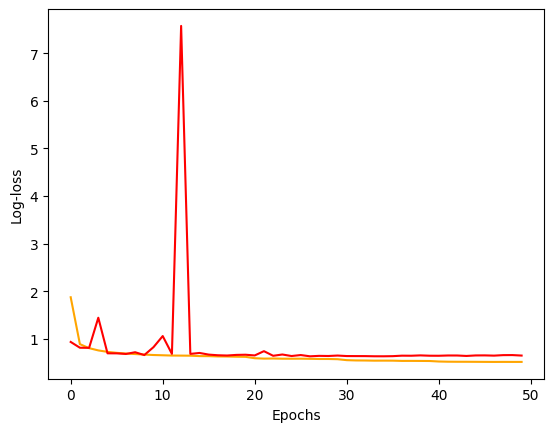

In [86]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

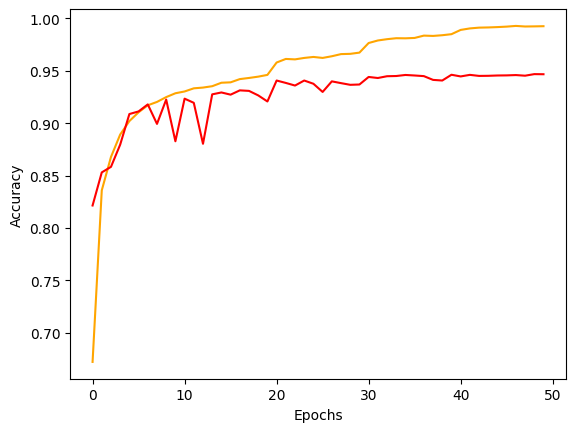

In [87]:
plt.plot(accu_epochs_train, color = 'orange')
plt.plot(accu_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy');

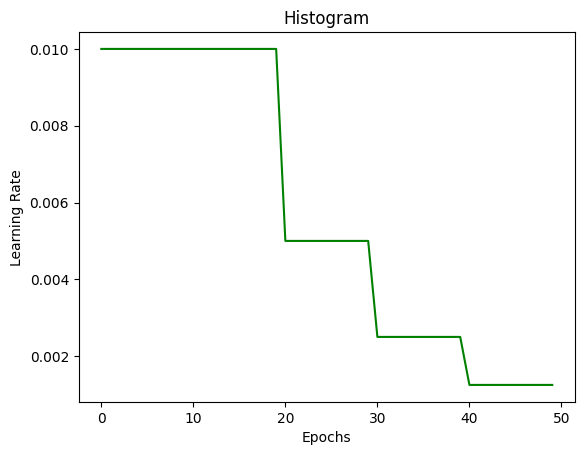

In [88]:
plt.plot(learning_rates, color = 'green')
plt.title('Histogram')
plt.xlabel('Epochs')
plt.ylabel('Learning Rate');

In [89]:
accu_epochs_train[49]

0.9925500154495239

In [90]:
accu_epochs_test[49]

0.9466999769210815

In [91]:
accu_epochs_test.max()

0.9467999935150146

This is a very good performance, actually, the best so far. The CIFAR-10 dataset is next.

In [92]:
torch.manual_seed(123)

transforms_cifar10_train =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize([0.4914, 0.4822, 0.4465], [0.2470, 0.2435, 0.2616]),
    torchvision.transforms.RandomHorizontalFlip(),
    torchvision.transforms.RandomResizedCrop(size=[32,32], scale = [0.8, 1.4]),
    ]
)

transforms_cifar10_test =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize([0.4914, 0.4822, 0.4465], [0.2470, 0.2435, 0.2616])]
)

cifar10_train = torchvision.datasets.CIFAR10(root = 'D:/nine circles 2', train = True,  download = True, transform = transforms_cifar10_train)
cifar10_test = torchvision.datasets.CIFAR10(root = 'D:/nine circles 2', train = False,  download = True, transform = transforms_cifar10_test)


cifar10_train_loader = DataLoader(dataset = cifar10_train, batch_size = 250, shuffle = True) 
cifar10_test_loader = DataLoader(dataset = cifar10_test, batch_size = 250, shuffle = False)

# inception initialization
Inception_resnet_v1_red_cuda = Inception_resnet_v1_red(10).to(cuda_device)

x = (cifar10_train.__getitem__(0)[0]).to(cuda_device)
x = x[None,:,:,:]
Inception_resnet_v1_red_cuda(x);
Inception_resnet_v1_red_cuda.apply(init_weights_he);

optim_SGD_cuda = torch.optim.Adam(Inception_resnet_v1_red_cuda.parameters(), lr = 0.01, betas=(0.9, 0.999), weight_decay = 0)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[20,30,40], gamma = 0.5)
cross_entropy_loss = nn.CrossEntropyLoss(label_smoothing=0.01)

n_epochs = 50

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t], accu_epochs_train[t], accu_epochs_test[t]  = train_test_loop_cuda(cifar10_train_loader, cifar10_test_loader, Inception_resnet_v1_red_cuda, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda)
end = time.time()
print(end - start)

1859.6224117279053


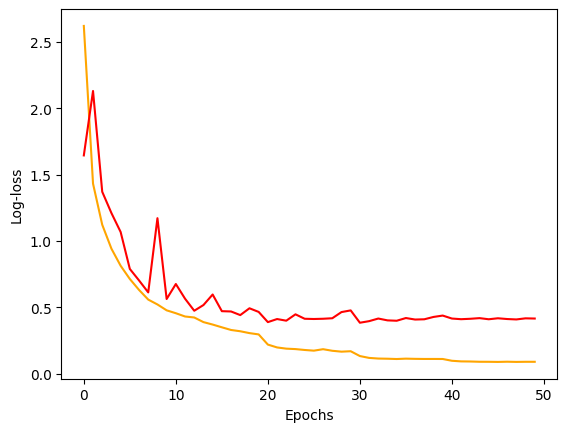

In [93]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

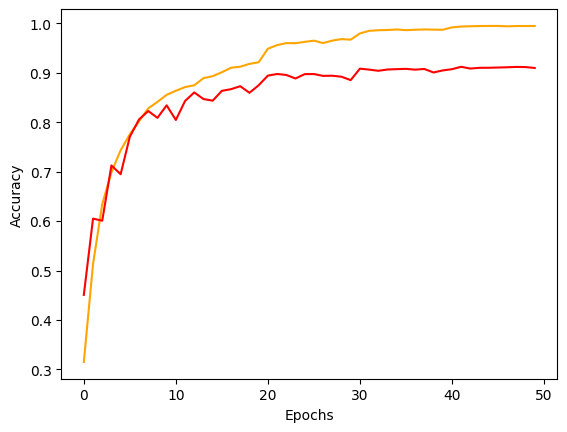

In [94]:
plt.plot(accu_epochs_train, color = 'orange')
plt.plot(accu_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy');

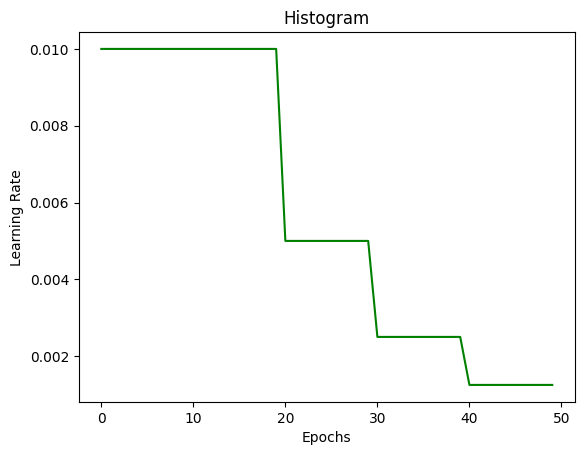

In [95]:
plt.plot(learning_rates, color = 'green')
plt.title('Histogram')
plt.xlabel('Epochs')
plt.ylabel('Learning Rate');

In [96]:
accu_epochs_train[49]

0.9947199821472168

In [97]:
accu_epochs_test[49]

0.9097999930381775

In [98]:
accu_epochs_test.max()

0.9121999740600586

Unfortunately, this performance is not so great. We would have to tweak our simplified Inception-ResNet model a bit more.

## ResNeXt <a class="anchor" id="resnet-block"></a>

The final network architecture we will introduce in this project is ResNext [[6](#6)] from 2017. ResNeXt is a continuation of Inception in the sense of using blocks with multiple branches. However, unlike Inception, the branches in the ResNeXt block are all identical. The resulting operation is known as a *group convolution*, and its main advantage over the usual convolution is a much lower number of parameters: the convolution kernel in each group is applied only to a limited number of channels that belong to its group instead of all of them. This is an important observation used in later convolutional neural networks designed for smaller devices (i.e., mobile phones) with limited memory. 

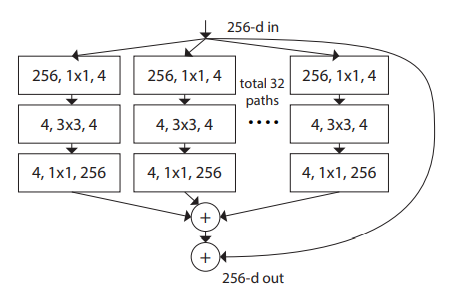

In [99]:
class ResNeXtBlock(nn.Module): 

    def __init__(self, num_ouput_channels, group_channels_total, num_groups, conv1x1 = False, strides = 1):
        super().__init__()

        self.conv1 = nn.LazyConv2d(group_channels_total, kernel_size=1, stride=1)
        self.conv2 = nn.LazyConv2d(group_channels_total, kernel_size=3, stride=strides, padding=1, groups = num_groups)
        self.conv3 = nn.LazyConv2d(num_ouput_channels, kernel_size=1, stride=1)
    
        self.bn1 = nn.LazyBatchNorm2d()
        self.bn2 = nn.LazyBatchNorm2d()
        self.bn3 = nn.LazyBatchNorm2d()
    
        if conv1x1:
            self.conv4 = nn.LazyConv2d(num_ouput_channels, kernel_size=1, stride=strides)
            self.bn4 = nn.LazyBatchNorm2d()
        else:
            self.conv4 = None
        
    def forward(self, X):
        Y = torch.nn.functional.relu(self.bn1(self.conv1(X)))
        Y = torch.nn.functional.relu(self.bn2(self.conv2(Y)))
        Y = self.bn3(self.conv3(Y))
        
        if self.conv4:
            X = self.bn4(self.conv4(X))
            
        return torch.nn.functional.relu(Y + X)

We will implement ResNeXt-50 using the following table from [[6](#6)].

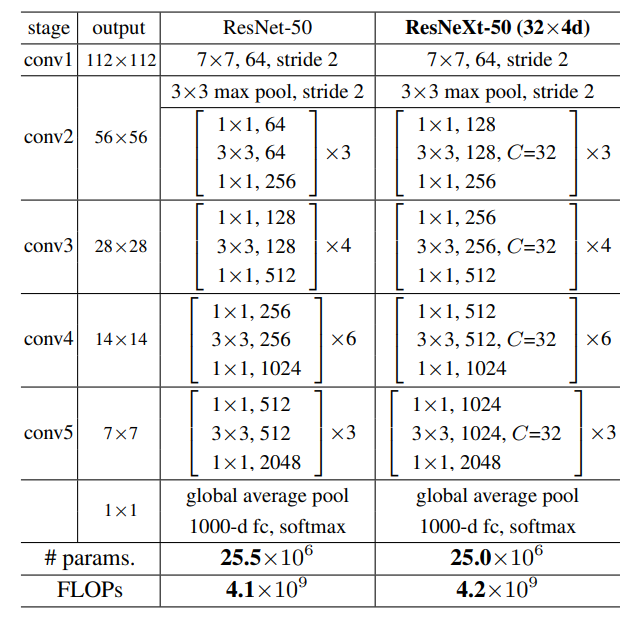

In [100]:
class ResNeXt_50(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

         # block 1
        self.b1 = nn.Sequential(
            nn.LazyConv2d(64, kernel_size=7, stride=2, padding=3),  nn.LazyBatchNorm2d(), nn.ReLU(), 
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )
        
        # residual blocks
        self.b2 =  nn.Sequential(
            ResNeXtBlock(256, 128, 32, conv1x1 = True),
            ResNeXtBlock(256, 128, 32),
            ResNeXtBlock(256, 128, 32),
            ResNeXtBlock(512, 256, 32, strides = 2, conv1x1 = True),
            ResNeXtBlock(512, 256, 32),
            ResNeXtBlock(512, 256, 32),
            ResNeXtBlock(512, 256, 32),
            ResNeXtBlock(1024, 512, 32, strides = 2, conv1x1 = True),
            ResNeXtBlock(1024, 512, 32),
            ResNeXtBlock(1024, 512, 32),
            ResNeXtBlock(1024, 512, 32),
            ResNeXtBlock(1024, 512, 32),
            ResNeXtBlock(1024, 512, 32),
            ResNeXtBlock(2048, 1024, 32, strides = 2, conv1x1 = True),
            ResNeXtBlock(2048, 1024, 32),
            ResNeXtBlock(2048, 1024, 32),
        )

        self.net_stack = nn.Sequential(
            self.b1, self.b2,  nn.AdaptiveAvgPool2d((1,1)), nn.Flatten(),
            nn.LazyLinear(num_classes)
        )

    def forward(self, x):
        output = self.net_stack(x)
        return output

In [101]:
layer_summary(ResNeXt_50(10),(1, 1, 64, 64))

Sequential output shape:	 torch.Size([1, 64, 16, 16])
Sequential output shape:	 torch.Size([1, 2048, 2, 2])
AdaptiveAvgPool2d output shape:	 torch.Size([1, 2048, 1, 1])
Flatten output shape:	 torch.Size([1, 2048])
Linear output shape:	 torch.Size([1, 10])


Again, we will first evaluate the performance on the upscaled Fashion-MNIST dataset.

In [102]:
torch.manual_seed(123)

# data loader
transforms_fashion_mnist_train =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(0.5, 0.5),
    torchvision.transforms.RandomHorizontalFlip(),
    torchvision.transforms.RandomResizedCrop(size = [64, 64], scale = [0.9,1.1]) 
    ]
)

transforms_fashion_mnist_test =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Resize([64,64]),
    torchvision.transforms.Normalize(0.5, 0.5)]
)

fashion_mnist_train = torchvision.datasets.FashionMNIST(root = 'D:/nine circles 2', train = True,  download = True, transform = transforms_fashion_mnist_train)
fashion_mnist_test = torchvision.datasets.FashionMNIST(root = 'D:/nine circles 2', train = False,  download = True, transform = transforms_fashion_mnist_test)

fashion_mnist_train_loader = DataLoader(dataset = fashion_mnist_train, batch_size = 250, shuffle = True) 
fashion_mnist_test_loader = DataLoader(dataset = fashion_mnist_test, batch_size = 250, shuffle = False)  


# resnext initialization
ResNeXt_50_cuda = ResNeXt_50(10).to(cuda_device)

x = (fashion_mnist_train.__getitem__(0)[0]).to(cuda_device)
x = x[None,:,:,:]
ResNeXt_50_cuda(x);
ResNeXt_50_cuda.apply(init_weights_he);

In [103]:
sum(p.numel() for p in ResNeXt_50_cuda.parameters() if p.requires_grad)

23028234

In [104]:
optim_SGD_cuda =  torch.optim.Adam(ResNeXt_50_cuda.parameters(), lr = 0.01, betas=(0.9, 0.999), weight_decay = 0)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[20, 30, 40], gamma = 0.5)
cross_entropy_loss = nn.CrossEntropyLoss(label_smoothing=0.1)

n_epochs = 50

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t], accu_epochs_train[t], accu_epochs_test[t]   = train_test_loop_cuda(fashion_mnist_train_loader, fashion_mnist_test_loader, ResNeXt_50_cuda, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda)
end = time.time()
print(end - start)

2216.6321144104004


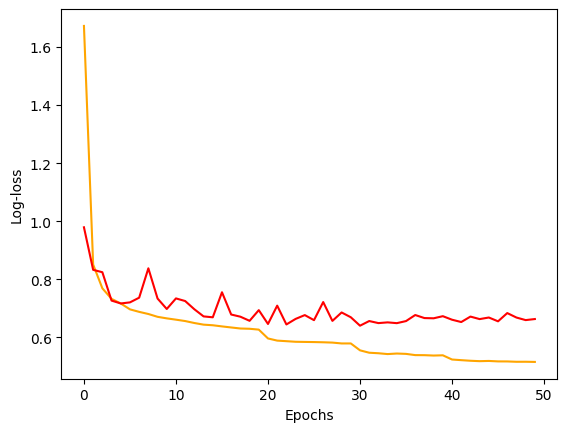

In [105]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

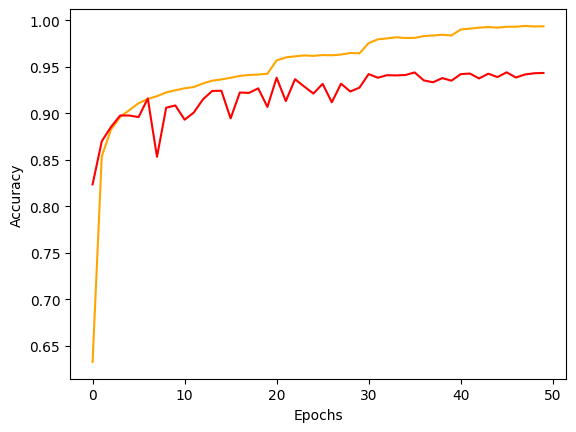

In [106]:
plt.plot(accu_epochs_train, color = 'orange')
plt.plot(accu_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy');

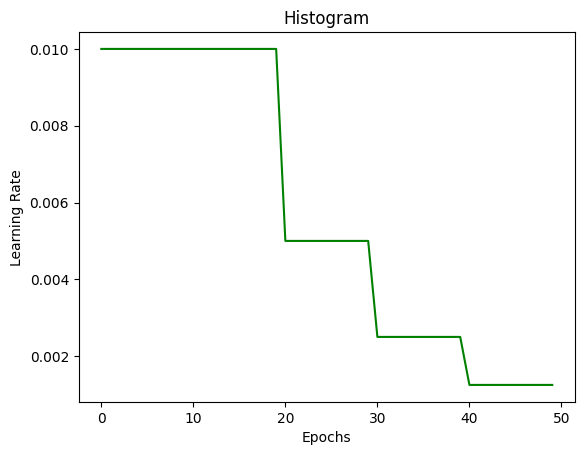

In [107]:
plt.plot(learning_rates, color = 'green')
plt.title('Histogram')
plt.xlabel('Epochs')
plt.ylabel('Learning Rate');

In [108]:
accu_epochs_train[49]

0.9934166669845581

In [109]:
accu_epochs_test[49]

0.9432999491691589

In [110]:
accu_epochs_test.max()

0.9440000057220459

From the get-go, we have obtained a very good performance. 

As the final step of this project, we will again slightly modify the model and test it on the CIFAR-10 dataset.

In [111]:
class ResNeXt_50_red(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

         # block 1
        self.b1 = nn.Sequential(
            nn.LazyConv2d(64, kernel_size=3, stride=1, padding=1),  nn.LazyBatchNorm2d(), nn.ReLU(), 
        )
        
        # residual blocks
        self.b2 =  nn.Sequential(
            ResNeXtBlock(256, 4*16, 4, conv1x1 = True),
            ResNeXtBlock(256, 4*16, 4),
            ResNeXtBlock(256, 4*16, 4),
            ResNeXtBlock(512, 4*32, 4, strides = 2, conv1x1 = True),
            ResNeXtBlock(512, 4*32, 4),
            ResNeXtBlock(512, 4*32, 4),
            ResNeXtBlock(1024, 4*64, 4, strides = 2, conv1x1 = True),
            ResNeXtBlock(1024, 4*64, 4),
            ResNeXtBlock(1024, 4*64, 4)
        )

        self.net_stack = nn.Sequential(
            self.b1, self.b2,  nn.AdaptiveAvgPool2d((1,1)), nn.Flatten(),
            nn.LazyLinear(num_classes)
        )

    def forward(self, x):
        output = self.net_stack(x)
        return output

In [112]:
layer_summary(ResNeXt_50_red(10),(1, 1, 32, 32))

Sequential output shape:	 torch.Size([1, 64, 32, 32])
Sequential output shape:	 torch.Size([1, 1024, 8, 8])
AdaptiveAvgPool2d output shape:	 torch.Size([1, 1024, 1, 1])
Flatten output shape:	 torch.Size([1, 1024])
Linear output shape:	 torch.Size([1, 10])


In [113]:
torch.manual_seed(123)

transforms_cifar10_train =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize([0.4914, 0.4822, 0.4465], [0.2470, 0.2435, 0.2616]),
    torchvision.transforms.RandomHorizontalFlip(),
    torchvision.transforms.RandomResizedCrop(size=[32,32], scale = [0.8, 1.4]),
    ]
)

transforms_cifar10_test =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize([0.4914, 0.4822, 0.4465], [0.2470, 0.2435, 0.2616])]
)

cifar10_train = torchvision.datasets.CIFAR10(root = 'D:/nine circles 2', train = True,  download = True, transform = transforms_cifar10_train)
cifar10_test = torchvision.datasets.CIFAR10(root = 'D:/nine circles 2', train = False,  download = True, transform = transforms_cifar10_test)


cifar10_train_loader = DataLoader(dataset = cifar10_train, batch_size = 125, shuffle = True) 
cifar10_test_loader = DataLoader(dataset = cifar10_test, batch_size = 125, shuffle = False)

# resnext initialization
ResNeXt_50_cuda = ResNeXt_50_red(10).to(cuda_device)

x = (cifar10_train.__getitem__(0)[0]).to(cuda_device)
x = x[None,:,:,:]
ResNeXt_50_cuda(x);
ResNeXt_50_cuda.apply(init_weights_he);




In [114]:
sum(p.numel() for p in ResNeXt_50_cuda.parameters() if p.requires_grad)

3182346

In [115]:
optim_SGD_cuda = torch.optim.Adam(ResNeXt_50_cuda.parameters(), lr = 0.01, betas=(0.9, 0.999), weight_decay = 0)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[50], gamma = 0.1)
cross_entropy_loss = nn.CrossEntropyLoss(label_smoothing=0.1)

n_epochs = 100

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t], accu_epochs_train[t], accu_epochs_test[t]  = train_test_loop_cuda(cifar10_train_loader, cifar10_test_loader, ResNeXt_50_cuda, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda)
end = time.time()
print(end - start)

3402.991329908371


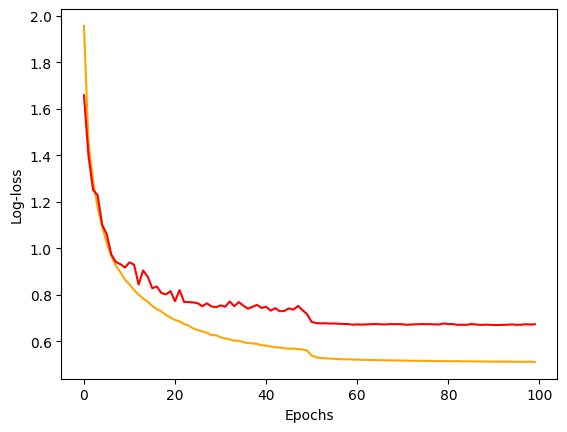

In [116]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

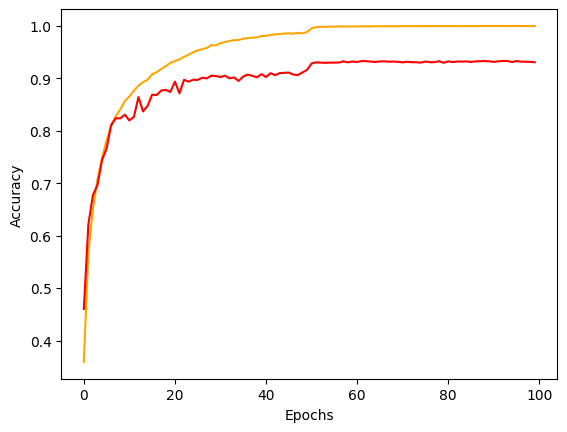

In [117]:
plt.plot(accu_epochs_train, color = 'orange')
plt.plot(accu_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy');

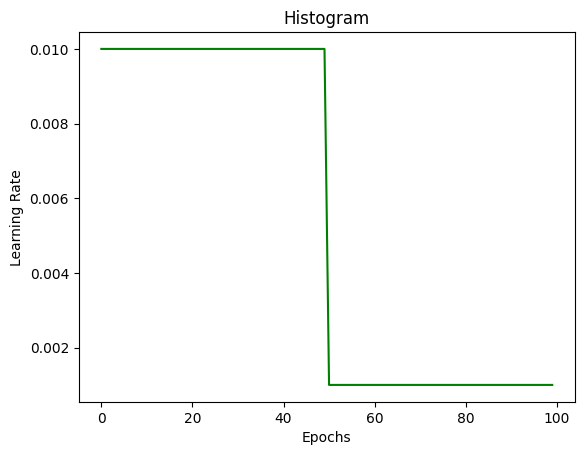

In [118]:
plt.plot(learning_rates, color = 'green')
plt.title('Histogram')
plt.xlabel('Epochs')
plt.ylabel('Learning Rate');

In [119]:
accu_epochs_train[99]

0.9997400045394897

In [120]:
accu_epochs_test[99]

0.9304999709129333

In [121]:
accu_epochs_test.max()

0.9328999519348145

The result matches our previous ResNet model (although we trained this model half as long).

## References <a class="anchor" id="references"></a>

<a id="1">[1]</a> HE, Kaiming, et al. Deep residual learning for image recognition. In: Proceedings of the IEEE conference on computer vision and pattern recognition. 2016. p. 770-778.

<a id="2">[2]</a> SIMONYAN, Karen; ZISSERMAN, Andrew. Very deep convolutional networks for large-scale image recognition. *arXiv preprint arXiv:1409.1556*, 2014.

<a id="3">[3]</a> XIAO, Han; RASUL, Kashif; VOLLGRAF, Roland. Fashion-mnist: a novel image dataset for benchmarking machine learning algorithms. arXiv preprint arXiv:1708.07747, 2017.

<a id="4">[4]</a> HUANG, Gao, et al. Deep networks with stochastic depth. In: European conference on computer vision. Cham: Springer International Publishing, 2016. p. 646-661.

<a id="5">[5]</a> SZEGEDY, Christian, et al. Inception-v4, inception-resnet and the impact of residual connections on learning. In: *Proceedings of the AAAI conference on artificial intelligence.* 2017.

<a id="6">[6] HUANG, Gao, et al. Densely connected convolutional networks. In: Proceedings of the IEEE conference on computer vision and pattern recognition. 2017. p. 4700-4708.
